# Adventure Works Sales Analysis (2015–2017)

## Overview
This project analyzes sales, customer behavior, and product returns for Adventure Works — a fictional bicycle retailer used as a standard business intelligence dataset. The analysis covers three years of transactional data across six related tables, linking sales with products, categories, customers, territories, and returns.

**Data source:** Maven Analytics — Adventure Works Dataset

**Tools:** Python, pandas, matplotlib, SQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv('AdventureWorks_Customers.csv', encoding='latin-1')
sales_2015 = pd.read_csv('AdventureWorks_Sales_2015.csv')
sales_2016 = pd.read_csv('AdventureWorks_Sales_2016.csv')
sales_2017 = pd.read_csv('AdventureWorks_Sales_2017.csv')
products = pd.read_csv('AdventureWorks_Products.csv')
product_categories = pd.read_csv('AdventureWorks_Product_Categories.csv')
product_subcategories = pd.read_csv('AdventureWorks_Product_Subcategories.csv')
territories = pd.read_csv('AdventureWorks_Territories.csv')
returns = pd.read_csv('AdventureWorks_Returns.csv')

In [3]:
sales = pd.concat([sales_2015, sales_2016, sales_2017], ignore_index=True)

In [4]:
sales.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity
0,1/1/2015,9/21/2001,SO45080,332,14657,1,1,1
1,1/1/2015,12/5/2001,SO45079,312,29255,4,1,1
2,1/1/2015,10/29/2001,SO45082,350,11455,9,1,1
3,1/1/2015,11/16/2001,SO45081,338,26782,6,1,1
4,1/2/2015,12/15/2001,SO45083,312,14947,10,1,1


In [5]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 56046 entries, 0 to 56045
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   OrderDate      56046 non-null  str  
 1   StockDate      56046 non-null  str  
 2   OrderNumber    56046 non-null  str  
 3   ProductKey     56046 non-null  int64
 4   CustomerKey    56046 non-null  int64
 5   TerritoryKey   56046 non-null  int64
 6   OrderLineItem  56046 non-null  int64
 7   OrderQuantity  56046 non-null  int64
dtypes: int64(5), str(3)
memory usage: 3.4 MB


In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 18148 entries, 0 to 18147
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerKey     18148 non-null  int64
 1   Prefix          18018 non-null  str  
 2   FirstName       18148 non-null  str  
 3   LastName        18148 non-null  str  
 4   BirthDate       18148 non-null  str  
 5   MaritalStatus   18148 non-null  str  
 6   Gender          18018 non-null  str  
 7   EmailAddress    18148 non-null  str  
 8   AnnualIncome    18148 non-null  str  
 9   TotalChildren   18148 non-null  int64
 10  EducationLevel  18148 non-null  str  
 11  Occupation      18148 non-null  str  
 12  HomeOwner       18148 non-null  str  
dtypes: int64(2), str(11)
memory usage: 1.8 MB


In [7]:
customers.head(10)

,CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
0,11000,MR.,JON,YANG,4/8/1966,M,M,jon24@adventure-works.com,"$90,000",2,Bachelors,Professional,Y
1,11001,MR.,EUGENE,HUANG,5/14/1965,S,M,eugene10@adventure-works.com,"$60,000",3,Bachelors,Professional,N
2,11002,MR.,RUBEN,TORRES,8/12/1965,M,M,ruben35@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
3,11003,MS.,CHRISTY,ZHU,2/15/1968,S,F,christy12@adventure-works.com,"$70,000",0,Bachelors,Professional,N
4,11004,MRS.,ELIZABETH,JOHNSON,8/8/1968,S,F,elizabeth5@adventure-works.com,"$80,000",5,Bachelors,Professional,Y
5,11005,MR.,JULIO,RUIZ,8/5/1965,S,M,julio1@adventure-works.com,"$70,000",0,Bachelors,Professional,Y
6,11007,MR.,MARCO,MEHTA,5/9/1964,M,M,marco14@adventure-works.com,"$60,000",3,Bachelors,Professional,Y
7,11008,MRS.,ROBIN,VERHOFF,7/7/1964,S,F,rob4@adventure-works.com,"$60,000",4,Bachelors,Professional,Y
8,11009,MR.,SHANNON,CARLSON,4/1/1964,S,M,shannon38@adventure-works.com,"$70,000",0,Bachelors,Professional,N
9,11010,MS.,JACQUELYN,SUAREZ,2/6/1964,S,F,jacquelyn20@adventure-works.com,"$70,000",0,Bachelors,Professional,N


In [8]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             293 non-null    int64  
 1   ProductSubcategoryKey  293 non-null    int64  
 2   ProductSKU             293 non-null    str    
 3   ProductName            293 non-null    str    
 4   ModelName              293 non-null    str    
 5   ProductDescription     293 non-null    str    
 6   ProductColor           243 non-null    str    
 7   ProductSize            293 non-null    str    
 8   ProductStyle           293 non-null    str    
 9   ProductCost            293 non-null    float64
 10  ProductPrice           293 non-null    float64
dtypes: float64(2), int64(2), str(7)
memory usage: 25.3 KB


In [9]:
sales['ProductKey'].isin(products['ProductKey']).all()

np.True_

In [10]:
sales['CustomerKey'].isin(customers['CustomerKey']).all()

np.True_

In [11]:
sales['TerritoryKey'].isin(territories['SalesTerritoryKey']).all()

np.True_

In [12]:
sales['OrderDate'] = pd.to_datetime(sales['OrderDate'])
sales['StockDate'] = pd.to_datetime(sales['StockDate'])

In [13]:
products['ProductColor'].values.unique()

<StringArray>
[         'Red',        'Black',        'White',         'Blue',
        'Multi',       'Silver',       'Yellow',            nan,
         'Grey', 'Silver/Black']
Length: 10, dtype: str

In [14]:
products['ProductColor'] = products['ProductColor'].fillna('Unknown')

In [15]:
products['ProductColor'].values.unique()

<StringArray>
[         'Red',        'Black',        'White',         'Blue',
        'Multi',       'Silver',       'Yellow',      'Unknown',
         'Grey', 'Silver/Black']
Length: 10, dtype: str

In [16]:
customers['Gender'].values.unique()

<StringArray>
['M', 'F', nan]
Length: 3, dtype: str

In [17]:
customers['Prefix'].values.unique()

<StringArray>
['MR.', 'MS.', 'MRS.', nan]
Length: 4, dtype: str

In [18]:
customers['Gender'] = customers['Gender'].fillna('Other')
customers['Prefix'] = customers['Prefix'].fillna('Other')

In [19]:
sales_prod_merged = sales.merge(products, how='inner', on='ProductKey',)

In [20]:
sales_prod_merged['Revenue'] = sales_prod_merged['OrderQuantity'] * sales_prod_merged['ProductPrice']

In [21]:
top_10_revenue = sales_prod_merged.groupby('ProductName')['Revenue'].sum().round(2).sort_values(ascending=False).head(10)

In [22]:
sales_prod_subcat_merged = sales_prod_merged.merge(product_subcategories, how='inner', on='ProductSubcategoryKey')

In [23]:
sales_prod_subcat_cat_merged = sales_prod_subcat_merged.merge(product_categories, how='inner', on='ProductCategoryKey')

In [ ]:
top_3_revenue_cat = sales_prod_subcat_cat_merged.groupby('CategoryName')['Revenue'].sum().round(2).sort_values(ascending=False).head(10)

CategoryName
Bikes          23642495.10
Accessories      906673.11
Clothing         365418.62
Name: Revenue, dtype: float64

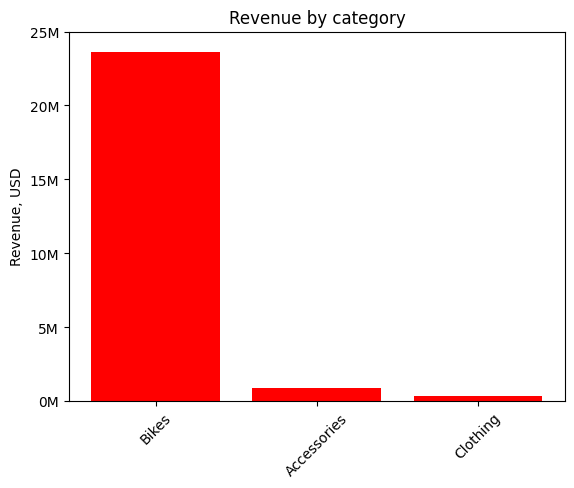

In [25]:
plt.bar(top_3_revenue_cat.index, top_3_revenue_cat.to_list(), color='red')
plt.ylabel('Revenue, USD')
plt.title('Revenue by category')
plt.xticks(rotation=45)
plt.yticks([0, 5_000_000, 10_000_000, 15_000_000, 20_000_000, 25_000_000], ['0M', '5M', '10M', '15M', '20M', '25M'])
plt.show()

Bikes is the dominant revenue category at Adventure Works, generating over $23.6M — almost 95% of total revenue across 2015–2017. Accessories and Clothing contribute marginally at $0.9M and $0.4M respectively.

In [26]:
sales_terr_merged = sales_prod_subcat_cat_merged.merge(territories, how='inner', left_on='TerritoryKey', right_on='SalesTerritoryKey')

In [27]:
revenue_by_country = sales_terr_merged.groupby('Country')['Revenue'].sum().round(2).sort_values()

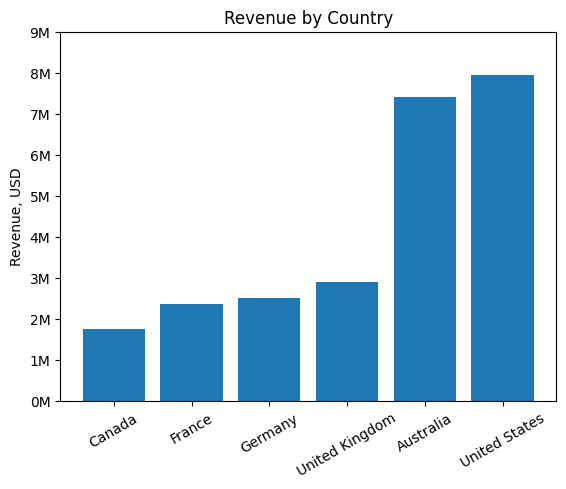

In [28]:
plt.bar(revenue_by_country.index, revenue_by_country.to_list())
plt.title('Revenue by Country')
plt.ylabel('Revenue, USD')
plt.yticks(range(0, 10_000_000, 1_000_000), ['0M', '1M', '2M', '3M', '4M', '5M', '6M', '7M', '8M', '9M'])
plt.xticks(rotation=30)
plt.show()

The United States and Australia are the top two markets, together generating over $15.5M — approximately 62% of total revenue. European markets (United Kingdom, Germany, France) collectively contribute around $7.5M, with each country showing comparable performance between $2M and $3M.

In [29]:
sales_by_year = sales_terr_merged.groupby(sales_terr_merged['OrderDate'].dt.year)['Revenue'].sum().round(2)

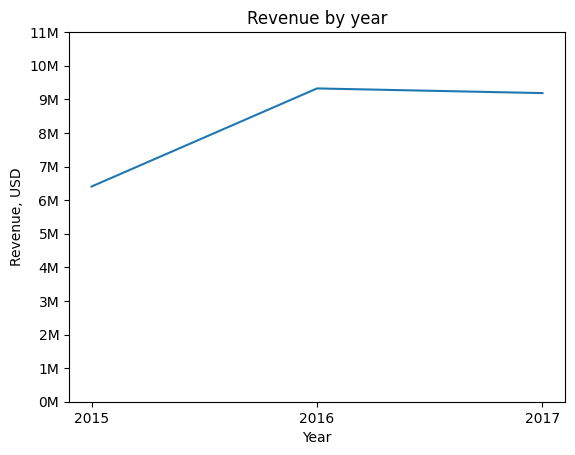

In [30]:
plt.plot(sales_by_year.index, sales_by_year.to_list())
plt.title('Revenue by year')
plt.xlabel('Year')
plt.ylabel('Revenue, USD')
plt.xticks([2015, 2016, 2017])
plt.yticks(range(0, 12_000_000, 1_000_000), ['0M', '1M', '2M', '3M', '4M', '5M', '6M', '7M', '8M', '9M', '10M', '11M'])
plt.show()

Revenue grew significantly from $6.4M in 2015 to $9.3M in 2016 — an increase of 45%. In 2017, revenue remained stable at $9.2M, suggesting the business reached a plateau after its initial growth phase.

In [31]:
def get_season(order_date):
    if 3 <= order_date.month <= 5:
        return 'Spring'
    elif 6 <= order_date.month <= 8:
        return 'Summer'
    elif 9 <= order_date.month <= 11:
        return 'Autumn'
    else:
        return 'Winter'
    
sales_terr_merged['Season'] = sales_terr_merged['OrderDate'].apply(get_season)

In [32]:
sales_by_season = sales_terr_merged.groupby('Season')['Revenue'].sum().round(2).reindex(['Winter', 'Spring', 'Summer', 'Autumn'])

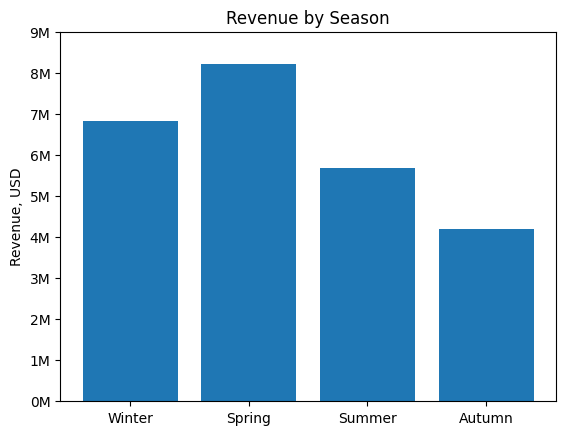

In [33]:
plt.bar(sales_by_season.index, sales_by_season.to_list())
plt.title('Revenue by Season')
plt.ylabel('Revenue, USD')
plt.yticks(range(0, 10_000_000, 1_000_000), ['0M', '1M', '2M', '3M', '4M', '5M', '6M', '7M', '8M', '9M'])
plt.show()

Sales follow a clear seasonal pattern: Spring generates the highest revenue ($8.2M), followed by Winter ($6.8M), suggesting that customers purchase bikes in advance of the active cycling season. Summer and Autumn show significantly lower demand at $5.7M and $4.2M respectively.

In [34]:
sales_final = sales_terr_merged.merge(customers, how='inner', on='CustomerKey')

In [35]:
piv_revenue = pd.pivot_table(sales_final, index='Country', columns='Gender', values='Revenue', aggfunc=sum).round(2)

Revenue is distributed almost equally between male and female customers across all countries, with no country showing a gender gap above 10%. This suggests that gender-based marketing segmentation would not be effective for this business.

In [36]:
top_10_customers = (sales_final.groupby(['CustomerKey', 'FirstName', 'LastName'])['Revenue']
    .sum().round(2)
    .sort_values(ascending=False).head(10)
    .reset_index()
    .sort_values(by='Revenue'))

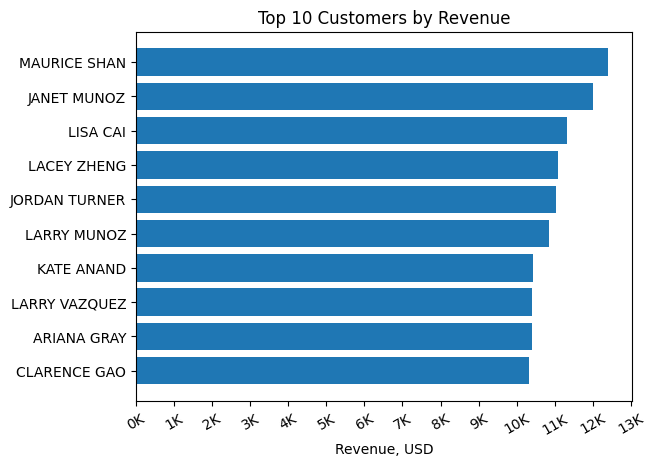

In [37]:
plt.barh([f'{first} {last}' for first, last in zip(top_10_customers['FirstName'], top_10_customers['LastName'])], top_10_customers['Revenue'])
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue, USD')
plt.xticks(range(0, 14000, 1000), ['0K', '1K', '2K', '3K', '4K', '5K', '6K', '7K', '8K', '9K', '10K', '11K', '12K', '13K'], rotation=30)
plt.show()

The top customer, Maurice Shan, generated $12,408 in total revenue over 2015–2017. All top 10 customers fall within a narrow range of $10K–$12.5K, suggesting no single customer has a dominant share — revenue is distributed relatively evenly among the best buyers.

In [38]:
returns_merged = (returns.merge(products, how='inner', on='ProductKey').merge(product_subcategories, how='inner', on='ProductSubcategoryKey')
    .merge(product_categories, how='inner', on='ProductCategoryKey'))
returns_merged['ReturnValue'] = returns_merged['ProductPrice'] * returns_merged['ReturnQuantity']

In [39]:
top_3_return_cat = returns_merged.groupby('CategoryName')['ReturnValue'].sum().round(2).sort_values(ascending=False).head(10)

In [40]:
top_cat = pd.concat([top_3_revenue_cat, top_3_return_cat], axis=1)

In [41]:
top_cat['ReturnRate'] = (top_cat['ReturnValue'] / top_cat['Revenue'] * 100).round(2)

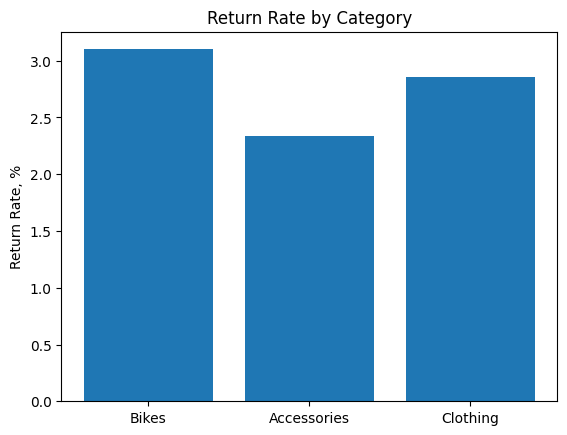

In [42]:
plt.bar(top_cat.index, top_cat['ReturnRate'])
plt.title('Return Rate by Category')
plt.ylabel('Return Rate, %')
plt.show()

The return rate is consistent across all categories, ranging from 2.34% (Accessories) to 3.10% (Bikes). This suggests no systematic quality issues within any specific product category.